## 모멘텀 + 리스크 패리티(Risk Parity) 기반 ETF 로테이션 전략
- 기존의 단순 모멘텀 전략과 차별화되는 점은 변동성을 고려한 가중치 조정이 포함
- 이 전략은 단순 모멘텀 전략보다 위험 조정 후 수익률(Risk-Adjusted Return)을 개선할 가능성이 있음
- 다만, 리스크 패리티 가중치를 적용함으로써 수익률이 극대화되지 않을 수도 있으며, 약한 모멘텀 종목의 비중이 커지는 단점이 있을 수 있음


✅ 모멘텀 기반 ETF 로테이션
✅ 매월 초 최근 20일 동안 가장 성과가 좋았던 ETF 10개를 선택
✅ 변동성이 높은 종목의 비중을 낮추고, 변동성이 낮은 종목의 비중을 높이는 리스크 패리티 적용
✅ 각 ETF에 가중치를 다르게 부여하여 변동성을 조절



### 1. 초기 설정 (initialize 함수)

- 투자 대상: sector_etfs 리스트에 포함된 ETF
- 과거 데이터 기간: 최근 20일 (context.history_window = 20)
- 보유할 종목 수: 10개 (context.stocks_to_hold = 10)
- 거래 시점: 매월 첫 거래일에 시장 마감 직전(date_rules.month_start(), time_rules.market_close())


### 2. 월간 변동성 계산 (calculate_volatility 함수)
- 변동성(Volatility) 정의: 수익률의 표준편차


### 3. 리스크 패리티 기반 가중치 계산 (calculate_risk_parity_weights 함수)

- 리스크 패리티(Risk Parity) 원칙:
- 변동성이 높은 자산은 비중을 낮추고, 변동성이 낮은 자산은 비중을 높이는 방식
- 변동성의 역수를 활용하여 가중치를 조정
가중치 = 변동성 / sum(변동성)


### 4. 매월 리밸런싱 (handle_data 함수)

- 모든 ETF의 최근 20일 수익률을 계산
- 모멘텀 상위 10개 ETF 선정 (top_performers)
- 선정된 ETF들의 변동성 계산 (selected_vol_table)
- 변동성 기반 리스크 패리티 가중치 계산 (weights)
- 계산된 가중치를 적용해 매수 주문
- 선정되지 않은 나머지 ETF는 비중을 0으로 설정(전량 매도)


### 5. 성과 분석 (analyze 함수)
- pyfolio 라이브러리를 활용하여 성과 분석
- pf.create_returns_tear_sheet()를 이용해 수익률 분석 리포트 생성

In [5]:
from zipline import run_algorithm
from zipline.api import symbol, order_target_percent, schedule_function, date_rules, time_rules
from datetime import datetime
import pyfolio as pf
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

In [6]:
sector_etfs = [
    'SPY',  # Financials
    'GLD',  # Technology
    'XLE',  # Energy
    'TLT',  # Consumer Discretionary
    'XLK',  # Consumer Staples
    'XLU',  # Health Care
    'XLP',  # Industrials
    'COPX',  # Materials
    'XLB',  # Utilities
    'EWZ',   # Real Estate
    'XLV',  # Industrials
    'XLI',  # Materials
    'XLY',  # Utilities
    'XLF',  # Utilities
    'XLC',  # Utilities
    'OIH',  # Utilities
    'EWJ',  # Utilities
]

In [7]:
def initialize(context) -> None:
    context.universe = [symbol(s) for s in sector_etfs]
    context.history_window = 20  # 변동성 및 수익률 계산을 위한 기간
    context.stocks_to_hold = 10  # 보유할 최대 종목 수
    schedule_function(func=handle_data,
                      date_rule=date_rules.month_start(),
                      time_rule=time_rules.market_close(),
                      half_days=True, calendar=None)

# 월간 변동성 계산
def calculate_volatility(ts: "time series") -> float:
    return ts.pct_change().std()

# 리스크 패리티에 기반한 가중치 계산
def calculate_risk_parity_weights(perf_table, vol_table):
    # 변동성의 역수를 기준으로 가중치 계산
    inverse_vol = 1 / vol_table
    normalized_weights = inverse_vol / inverse_vol.sum()
    return normalized_weights

def handle_data(context, data):
    # 과거 데이터 로드 (종가 기준)
    hist = data.history(assets=context.universe, fields="close", bar_count=context.history_window, frequency='1d')

    # 월간 수익률 계산
    perf_table = hist.apply(lambda ts: ts[-1] / ts[0] - 1)

    # 월간 변동성 계산
    vol_table = hist.apply(calculate_volatility)

    # 상위 N개 종목 선택
    top_performers = perf_table.sort_values(ascending=False)[:context.stocks_to_hold]
    selected_vol_table = vol_table[top_performers.index]

    # 리스크 패리티 기반 가중치 계산
    weights = calculate_risk_parity_weights(top_performers, selected_vol_table)

    # 종목별 주문
    for stock, weight in weights.items():
        if data.can_trade(stock):
            order_target_percent(stock, weight)

    # 나머지 종목은 비중 0으로 설정
    for stock in context.universe:
        if stock not in weights.index and data.can_trade(stock):
            order_target_percent(stock, 0.0)

def analyze(context, perf):
    # Zipline의 퍼포먼스 데이터를 분석
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf)
    pf.create_returns_tear_sheet(returns, benchmark_rets=None)


In [10]:
start_date = pd.Timestamp('2010-01-01').tz_localize(None)
end_date = pd.Timestamp('2024-07-01').tz_localize(None)

Start date,2010-01-04
End date,2024-07-01
Total months,173
,Backtest
Annual return,8.179%
Cumulative returns,211.989%
Annual volatility,13.208%
Sharpe ratio,0.66
Calmar ratio,0.37
Stability,0.95
Max drawdown,-22.37%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,22.37,2022-04-04,2022-09-30,2024-04-03,523
1,21.60,2020-02-19,2020-03-23,2020-06-02,75
2,17.14,2018-01-26,2018-12-24,2020-01-02,505
3,15.55,2015-05-04,2016-01-20,2017-02-10,465
4,13.09,2011-07-07,2011-10-03,2011-10-28,82


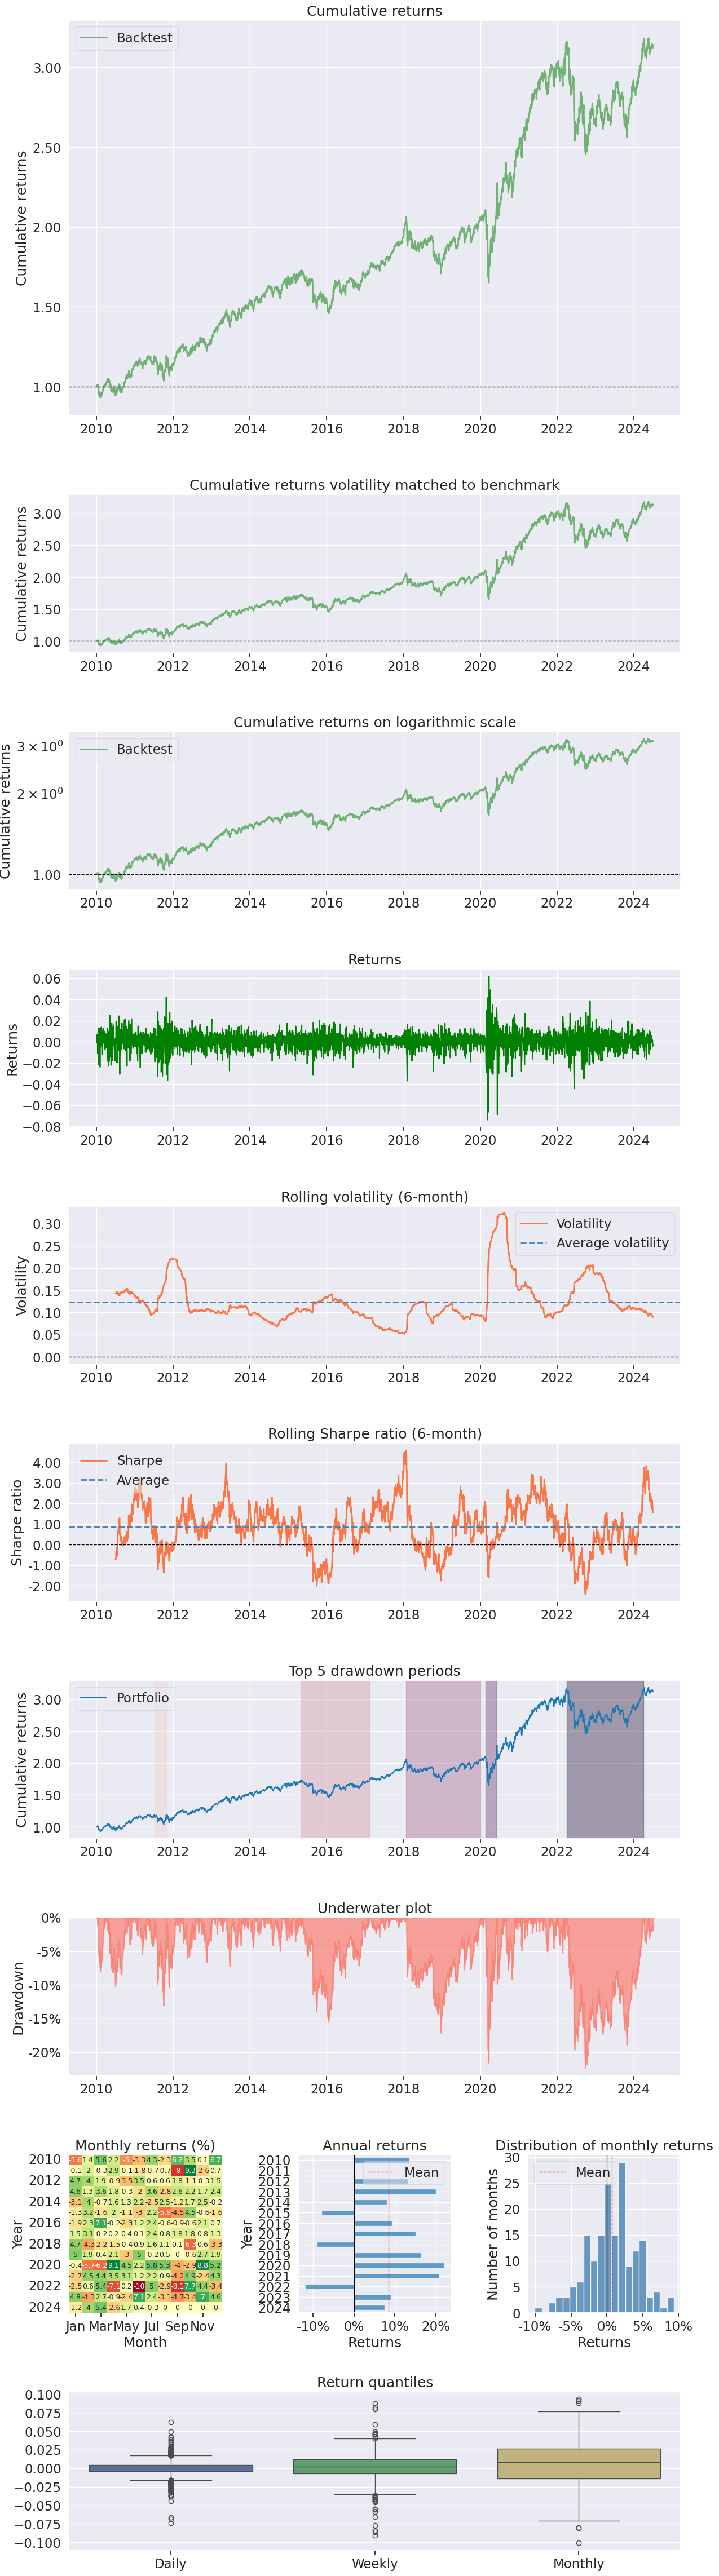

In [11]:
results = run_algorithm(
    start=start_date,
    end=end_date,
    initialize=initialize,
    handle_data=handle_data,
    analyze=analyze,
    capital_base=10000,
    data_frequency='daily',
    bundle='us_etfs'
)